#  Customer Churn Prediction using Logistic Regression

## Codveda Technologies - Machine Learning Internship

### Intern Information

**Name:** Muhammed Mumeenat

**Internship:** Machine Learning Internship

**Level:** Level 2 (Intermediate)

**Task:** Logistic Regression for Binary Classification

**Project:** Customer Churn Prediction using Logistic Regression



# Project Objective

The objective of this project is to build a Logistic Regression model that predicts whether a customer is likely to churn based on telecom service information.

The project covers data preprocessing, feature engineering, model training, evaluation using classification metrics, and interpretation of model coefficients and odds ratios using Python and Scikit-learn.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# 2. Loading the Dataset

The customer churn dataset is loaded into a Pandas DataFrame.

Each row represents a telecom customer, while each column contains information about the customer's account, usage, and whether they churned.

In [5]:
df = pd.read_csv("../datasets/churn-bigml-80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### Observation

The dataset contains customer information from a telecom company.

The target variable is **Churn**, which indicates whether a customer left the service or remained with the company.

Since the target has only two possible outcomes (True or False), this is a **binary classification** problem, making Logistic Regression an appropriate algorithm for this task.

# 3. Exploring the Dataset

Before building a machine learning model, it is important to understand the dataset by examining its structure, data types, summary statistics, and checking for missing values.

In [7]:
df.shape

(2666, 20)

In [9]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [10]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [11]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

### Observation

From exploring the dataset, the following observations were made:

- The dataset contains **2,666 rows** and **20 columns**.
- There are **no missing values**, so no data imputation is required.
- The dataset contains **numerical**, **categorical**, and **Boolean** features.
- The target variable is **Churn**, which is a Boolean column indicating whether a customer left the telecom company.
- Since Logistic Regression only works with numerical values, the categorical and Boolean variables must be converted into numerical form before training the model.

# 4. Encoding Categorical Variables

Machine learning algorithms require numerical input.

The categorical and Boolean columns are therefore converted into numerical values using Label Encoding before training the Logistic Regression model.

In [12]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Encode categorical columns
df["State"] = encoder.fit_transform(df["State"])
df["International plan"] = encoder.fit_transform(df["International plan"])
df["Voice mail plan"] = encoder.fit_transform(df["Voice mail plan"])

# Encode target column
df["Churn"] = encoder.fit_transform(df["Churn"])

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


# 5. Feature Selection

The dataset is divided into input features (X) and the target variable (y).

The input features contain the customer information that will be used to make predictions, while the target variable contains the churn status that the model will learn to predict.

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
print(X.shape, X.shape)
print(y.shape, y.shape)


(2666, 19) (2666, 19)
(2666,) (2666,)


# 6. Splitting the Dataset

The dataset is divided into training and testing sets.

The training set is used to teach the Logistic Regression model, while the testing set is used to evaluate how well the model performs on unseen data.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (2132, 19)
Testing Features: (534, 19)
Training Labels: (2132,)
Testing Labels: (534,)


### Observation

The dataset was split into training and testing sets using an 80:20 ratio.

The training set is used to teach the Logistic Regression model, while the testing set is reserved for evaluating the model's performance on unseen data.

# 7. Feature Scaling

The numerical features are standardized using StandardScaler.

Feature scaling ensures that all numerical variables are on a similar scale, preventing features with larger values from dominating the learning process.

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Observation

The training data was standardized using `fit_transform()`, allowing the scaler to learn the mean and standard deviation from the training set.

The testing data was standardized using `transform()` so that it uses the same scaling parameters learned from the training data, preventing data leakage and ensuring a fair model evaluation.

# 8. Training the Logistic Regression Model

A Logistic Regression model is created and trained using the standardized training data.

The model learns the relationship between the customer features and the churn status, enabling it to predict whether a customer is likely to leave the telecom service.

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

# 9. Making Predictions

After training the Logistic Regression model, predictions are made on the testing dataset.

The predicted values are then compared with the actual customer churn values to evaluate the model's performance.

In [17]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0
 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

# 10. Model Accuracy

Accuracy measures the percentage of correctly predicted customer churn outcomes.

A higher accuracy indicates better model performance.

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8595505617977528


# 11. Precision

Precision measures how many customers predicted to churn actually churned.

It is important when the cost of false positives is high.

In [19]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.5625


# 12. Recall

Recall measures how many of the actual churning customers were correctly identified by the model.

It is important when missing churning customers is costly.

In [20]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.22784810126582278


### Observation

The Logistic Regression model achieved an accuracy of approximately **85.96%**, indicating good overall performance.

However, the recall score is relatively low, meaning the model misses many customers who actually churn. This suggests that although the model predicts the majority class well, it struggles to identify all churning customers.

# 13. Confusion Matrix

A confusion matrix summarizes the prediction results by showing the number of correct and incorrect classifications.

It helps identify true positives, true negatives, false positives, and false negatives.

In [21]:
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)
print (cm)


[[441  14]
 [ 61  18]]


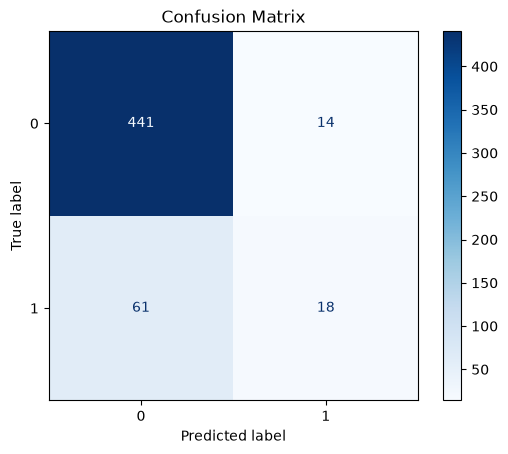

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

### Observation

The confusion matrix shows that the Logistic Regression model correctly classified most customers who did not churn.

However, it failed to identify many customers who actually churned, resulting in a relatively high number of false negatives. This explains the low recall score obtained during evaluation.

In [27]:
from sklearn.metrics import classification_report
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       455
           1       0.56      0.23      0.32        79

    accuracy                           0.86       534
   macro avg       0.72      0.60      0.62       534
weighted avg       0.83      0.86      0.83       534



### Observation

The classification report shows that the Logistic Regression model performs very well in predicting customers who do not churn.

However, its performance on the churn class is weaker, with relatively low recall and F1-score. This indicates that many customers who actually churn are not correctly identified by the model, likely due to class imbalance in the dataset.

# 15. Understanding Odds Ratio

Logistic Regression predicts the probability of an event occurring.

Instead of predicting a continuous value, it estimates the probability that an observation belongs to a particular class.

The model uses log-odds (logit), and the coefficients can be converted into Odds Ratios using the exponential function.

An Odds Ratio greater than 1 means the feature increases the likelihood of the positive class.

An Odds Ratio less than 1 means the feature decreases the likelihood of the positive class.

In [28]:
import pandas as pd
import numpy as np

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Odds Ratio"] = np.exp(coefficients["Coefficient"])

coefficients

,Feature,Coefficient,Odds Ratio
0,State,0.000479,1.000479
1,Account length,0.041977,1.042870
2,Area code,-0.053273,0.948121
3,International plan,0.667418,1.949199
4,Voice mail plan,-0.766362,0.464701
5,Number vmail messages,0.328090,1.388315
6,Total day minutes,0.371052,1.449259
7,Total day calls,0.074447,1.077289
8,Total day charge,0.370157,1.447962
9,Total eve minutes,0.144267,1.155193


### Observation

The Odds Ratio explains how each feature affects the likelihood of customer churn.

Features with Odds Ratios greater than 1 increase the odds of churn, while features with Odds Ratios less than 1 reduce the odds of churn.

This makes Logistic Regression more interpretable than many other classification algorithms.

# 16. Conclusion

In this project, a Logistic Regression model was developed to predict customer churn.

The dataset was explored, cleaned, encoded, and scaled before training the model.

Model performance was evaluated using Accuracy, Precision, Recall, Confusion Matrix, and Classification Report.

Although the model achieved good overall accuracy, its recall for churned customers was relatively low, indicating that many actual churn cases were missed.

Future improvements could include balancing the dataset, feature engineering, and experimenting with more advanced classification algorithms such as Random Forest, XGBoost, or Support Vector Machines.

In [29]:
import joblib

joblib.dump(model, "../models/logistic_regression_churn.pkl")

print("Model saved successfully!")

Model saved successfully!
